# Notebook 5 — Unsupervised Learning
**CRISP-DM Phase 4 | Chapter 4 Lab 4.3: Unsupervised Learning**

### Objectives
**Part 1 — Clustering Analysis** (unsupervised_learning.py reference)
- K-Means: elbow method + silhouette score for optimal k
- Hierarchical clustering with dendrogram
- DBSCAN density-based clustering
- Compare algorithms: silhouette, Davies-Bouldin, Calinski-Harabasz

**Part 2 — Dimensionality Reduction** (unsupervised_learning.py reference)
- PCA: explained variance, 2D projection
- t-SNE: non-linear manifold embedding
- LDA: supervised class-separation projection

**Application to Ethiopian Wealth Data**
- Cluster households by housing & asset features → do clusters recover quintiles?
- PCA on all features → principal determinants of wealth variation


## 1. Setup

In [3]:
import sys, os
sys.path.insert(0, os.path.join('..', 'src'))
%load_ext autoreload
%autoreload 2

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Clustering algorithms (Chapter 4 Lab 4.3 reference)
from sklearn.cluster        import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.decomposition  import PCA
from sklearn.manifold       import TSNE
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.preprocessing  import StandardScaler
from sklearn.metrics        import (silhouette_score, davies_bouldin_score,
                                    calinski_harabasz_score)
from scipy.cluster.hierarchy import dendrogram, linkage

# Project modules
from data_cleaner       import DataCleaner
from feature_enginner   import FeatureEngineer
from data_preprocesor   import DataPreprocessor

sns.set_theme(style='whitegrid')
COLORS5 = ['#d32f2f','#f57c00','#fbc02d','#388e3c','#1565c0']
print("✓ Setup complete")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
✓ Setup complete


## 2. Prepare Feature Matrix

In [4]:
df_raw   = pd.read_csv('../data/processed/all_waves_clean.csv')
df_clean = DataCleaner().fit_transform(df_raw)
df       = FeatureEngineer().engineer_all(df_clean)

# Feature matrix for clustering (housing + assets + demographics)
cluster_features = [
    'rooms','housing_score','housing_quality_idx',
    'has_electricity','owns_phone','owns_tv','owns_fridge',
    'modern_asset_score','improved_water','improved_sanitation',
    'head_edu_level','hh_size','adulteq','dependency_ratio',
    'hh_any_wage_earner','is_urban',
]
cluster_features = [c for c in cluster_features if c in df.columns]
df_cluster = df[cluster_features + ['cons_quint']].dropna()

X_clust = df_cluster[cluster_features].values
y_true  = df_cluster['cons_quint'].values.astype(int)

# Standardise (essential for K-Means, DBSCAN — Chapter 4 reference)
scaler  = StandardScaler()
X_scaled = scaler.fit_transform(X_clust)

print(f"Clustering matrix: {X_scaled.shape}")
print(f"True quintile distribution: {dict(zip(*np.unique(y_true, return_counts=True)))}")


Clustering matrix: (25349, 16)
True quintile distribution: {np.int64(1): np.int64(3886), np.int64(2): np.int64(3937), np.int64(3): np.int64(4482), np.int64(4): np.int64(5354), np.int64(5): np.int64(7690)}


## Part 1: Clustering Analysis
### Exercise 1: K-Means — Elbow Method + Silhouette Score (Chapter 4 Lab 4.3)


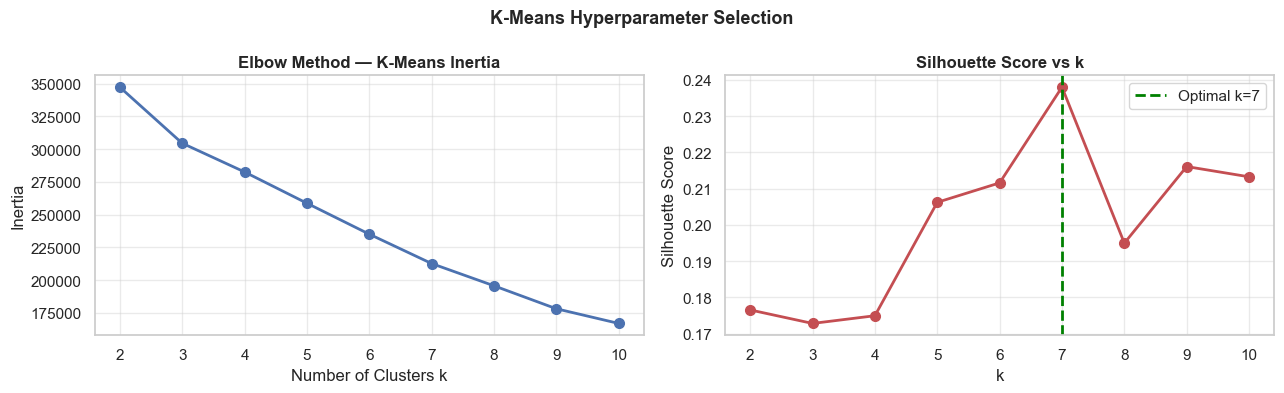

Optimal k = 7  (max silhouette = 0.2380)


In [5]:
# Elbow method + silhouette (Chapter 4 Lab 4.3 Exercise 2)
k_range         = range(2, 11)
inertias        = []
silhouette_list = []

for k in k_range:
    km  = KMeans(n_clusters=k, random_state=42, n_init=10)
    lbl = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouette_list.append(silhouette_score(X_scaled, lbl))

optimal_k = k_range[np.argmax(silhouette_list)]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Elbow curve
axes[0].plot(k_range, inertias, 'bo-', lw=2, ms=7)
axes[0].set_xlabel('Number of Clusters k'); axes[0].set_ylabel('Inertia')
axes[0].set_title('Elbow Method — K-Means Inertia', fontweight='bold')
axes[0].grid(alpha=0.4)

# Silhouette scores
axes[1].plot(k_range, silhouette_list, 'ro-', lw=2, ms=7)
axes[1].axvline(optimal_k, color='green', ls='--', lw=2,
                label=f'Optimal k={optimal_k}')
axes[1].set_xlabel('k'); axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score vs k', fontweight='bold')
axes[1].legend(); axes[1].grid(alpha=0.4)

plt.suptitle('K-Means Hyperparameter Selection', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/kmeans_elbow.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Optimal k = {optimal_k}  (max silhouette = {max(silhouette_list):.4f})")


In [6]:
# Fit optimal K-Means
km_opt      = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
km_labels   = km_opt.fit_predict(X_scaled)

# Cluster quality metrics
sil   = silhouette_score(X_scaled, km_labels)
db    = davies_bouldin_score(X_scaled, km_labels)
ch    = calinski_harabasz_score(X_scaled, km_labels)

print(f"K-Means (k={optimal_k}) Quality Metrics:")
print(f"  Silhouette Score (higher=better):        {sil:.4f}")
print(f"  Davies-Bouldin  (lower=better):          {db:.4f}")
print(f"  Calinski-Harabasz (higher=better):       {ch:.1f}")

# How well do clusters align with quintiles?
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
ari = adjusted_rand_score(y_true, km_labels)
nmi = normalized_mutual_info_score(y_true, km_labels)
print(f"\nAlignment with cons_quint:")
print(f"  Adjusted Rand Index (ARI): {ari:.4f}  (1=perfect, 0=random)")
print(f"  Normalised Mutual Info:    {nmi:.4f}")


K-Means (k=7) Quality Metrics:
  Silhouette Score (higher=better):        0.2380
  Davies-Bouldin  (lower=better):          1.3593
  Calinski-Harabasz (higher=better):       3833.8

Alignment with cons_quint:
  Adjusted Rand Index (ARI): 0.0045  (1=perfect, 0=random)
  Normalised Mutual Info:    0.0229


### Exercise 2: Hierarchical Clustering — Dendrogram (Chapter 4 Lab 4.3)

Hierarchical (k=7):  Silhouette=0.2161  DB=1.4668


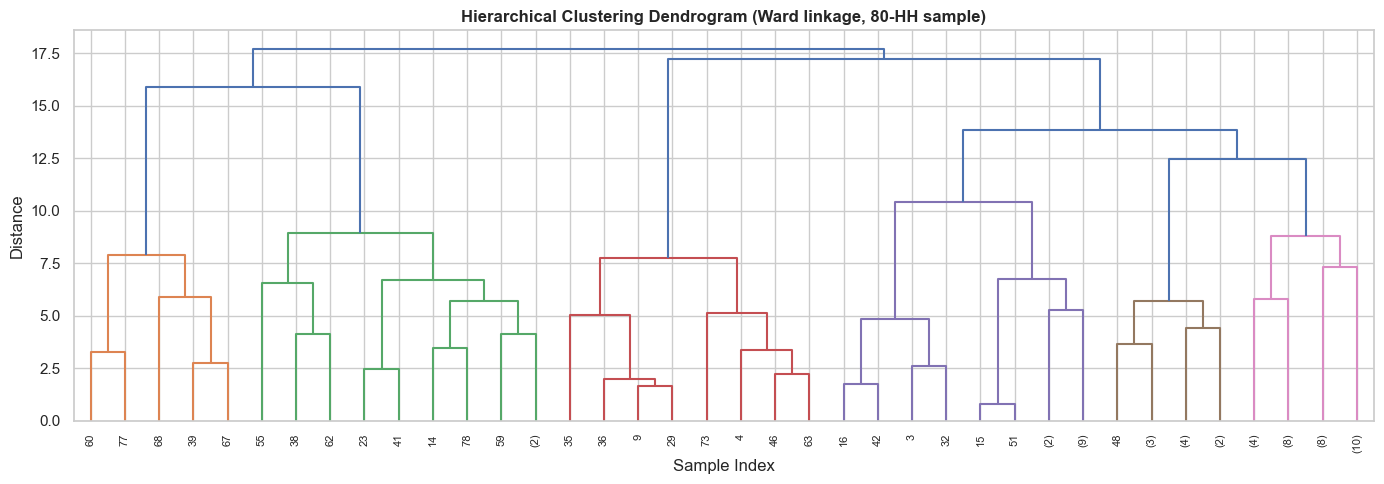

In [7]:
# Agglomerative clustering (Chapter 4 Lab 4.3 Exercise 3)
hier = AgglomerativeClustering(n_clusters=optimal_k, linkage='ward')
hier_labels = hier.fit_predict(X_scaled)

hier_sil = silhouette_score(X_scaled, hier_labels)
hier_db  = davies_bouldin_score(X_scaled, hier_labels)
print(f"Hierarchical (k={optimal_k}):  Silhouette={hier_sil:.4f}  DB={hier_db:.4f}")

# Dendrogram (Chapter 4 reference — use subset for clarity)
subset_idx = np.random.choice(len(X_scaled), min(80, len(X_scaled)),
                               replace=False)
lmat = linkage(X_scaled[subset_idx], method='ward')

fig, ax = plt.subplots(figsize=(14, 5))
dendrogram(lmat, ax=ax, truncate_mode='level', p=5,
           leaf_rotation=90, leaf_font_size=8, color_threshold=None)
ax.set_title('Hierarchical Clustering Dendrogram (Ward linkage, 80-HH sample)',
             fontweight='bold')
ax.set_xlabel('Sample Index'); ax.set_ylabel('Distance')
plt.tight_layout()
plt.savefig('../reports/dendrogram.png', dpi=150, bbox_inches='tight')
plt.show()


### Exercise 3: DBSCAN — Density-Based Clustering (Chapter 4 Lab 4.3)

In [8]:
# DBSCAN (Chapter 4 Lab 4.3 Exercise 4)
dbscan = DBSCAN(eps=0.8, min_samples=5)
db_labels = dbscan.fit_predict(X_scaled)

n_clusters = len(set(db_labels)) - (1 if -1 in db_labels else 0)
n_noise    = int((db_labels == -1).sum())
print(f"DBSCAN Results:")
print(f"  Clusters found:  {n_clusters}")
print(f"  Noise points:    {n_noise} ({n_noise/len(db_labels)*100:.1f}%)")

if n_clusters > 1:
    valid_mask = db_labels != -1
    db_sil = silhouette_score(X_scaled[valid_mask], db_labels[valid_mask])
    print(f"  Silhouette (non-noise): {db_sil:.4f}")
else:
    print("  Note: Only 1 cluster found — try adjusting eps or min_samples")


DBSCAN Results:
  Clusters found:  122
  Noise points:    5251 (20.7%)
  Silhouette (non-noise): 0.0471


### Exercise 4: Clustering Algorithm Comparison (Chapter 4 reference)

In [9]:
comparison = pd.DataFrame([
    {'Algorithm':'K-Means',       'k':optimal_k,
     'Silhouette': silhouette_score(X_scaled, km_labels),
     'Davies-Bouldin': davies_bouldin_score(X_scaled, km_labels),
     'Calinski-Harabasz': calinski_harabasz_score(X_scaled, km_labels),
     'ARI vs quintile': adjusted_rand_score(y_true, km_labels)},
    {'Algorithm':'Hierarchical',  'k':optimal_k,
     'Silhouette': silhouette_score(X_scaled, hier_labels),
     'Davies-Bouldin': davies_bouldin_score(X_scaled, hier_labels),
     'Calinski-Harabasz': calinski_harabasz_score(X_scaled, hier_labels),
     'ARI vs quintile': adjusted_rand_score(y_true, hier_labels)},
]).round(4)
print("Clustering Algorithm Comparison:")
comparison


Clustering Algorithm Comparison:


,Algorithm,k,Silhouette,Davies-Bouldin,Calinski-Harabasz,ARI vs quintile
0,K-Means,7,0.2380,1.3593,3833.8264,0.0045
1,Hierarchical,7,0.2161,1.4668,3779.5160,0.0060


## Part 2: Dimensionality Reduction
### Exercise 5: PCA — Principal Component Analysis (Chapter 4 Lab 4.3)


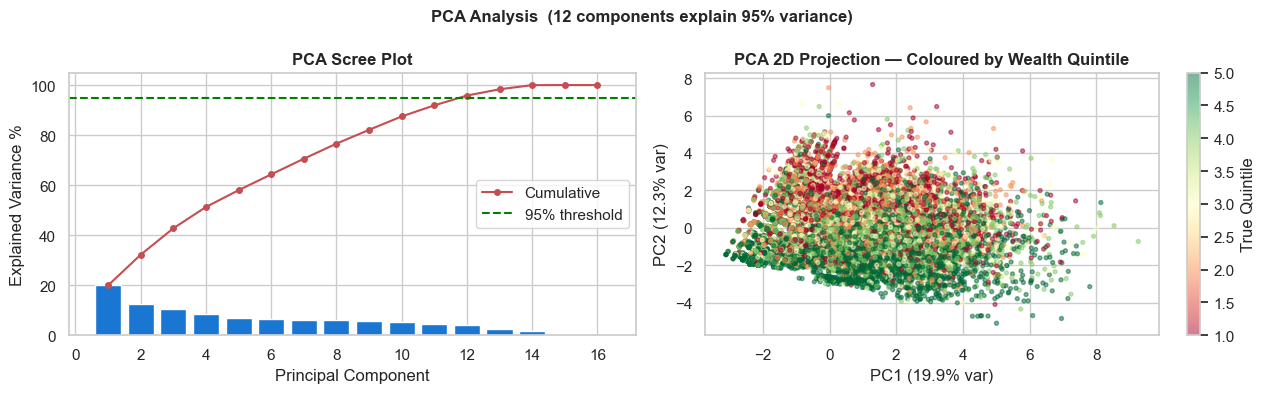


95% variance explained by 12 / 16 components


In [10]:
# Full PCA (Chapter 4 Lab 4.3 Exercise 6)
pca_full = PCA()
pca_full.fit(X_scaled)
exp_var  = pca_full.explained_variance_ratio_
cum_var  = np.cumsum(exp_var)
n95      = int(np.argmax(cum_var >= 0.95)) + 1

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Scree plot
axes[0].bar(range(1, len(exp_var)+1), exp_var * 100,
            color='#1976D2', edgecolor='white')
axes[0].plot(range(1, len(exp_var)+1), cum_var * 100,
             'ro-', ms=4, lw=1.5, label='Cumulative')
axes[0].axhline(95, color='green', ls='--', lw=1.5, label='95% threshold')
axes[0].set_xlabel('Principal Component'); axes[0].set_ylabel('Explained Variance %')
axes[0].set_title('PCA Scree Plot', fontweight='bold'); axes[0].legend()

# 2D PCA projection coloured by true quintile
pca_2d   = PCA(n_components=2)
X_pca_2d = pca_2d.fit_transform(X_scaled)
scatter  = axes[1].scatter(X_pca_2d[:,0], X_pca_2d[:,1],
                            c=y_true, cmap='RdYlGn', alpha=0.5, s=8)
plt.colorbar(scatter, ax=axes[1], label='True Quintile')
axes[1].set_xlabel(f'PC1 ({exp_var[0]:.1%} var)')
axes[1].set_ylabel(f'PC2 ({exp_var[1]:.1%} var)')
axes[1].set_title('PCA 2D Projection — Coloured by Wealth Quintile',
                  fontweight='bold')

plt.suptitle(f'PCA Analysis  ({n95} components explain 95% variance)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/pca_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"\n95% variance explained by {n95} / {len(exp_var)} components")


### Exercise 6: t-SNE — Non-linear Dimensionality Reduction (Chapter 4 Lab 4.3)

Running t-SNE (this may take 30–60 seconds)…


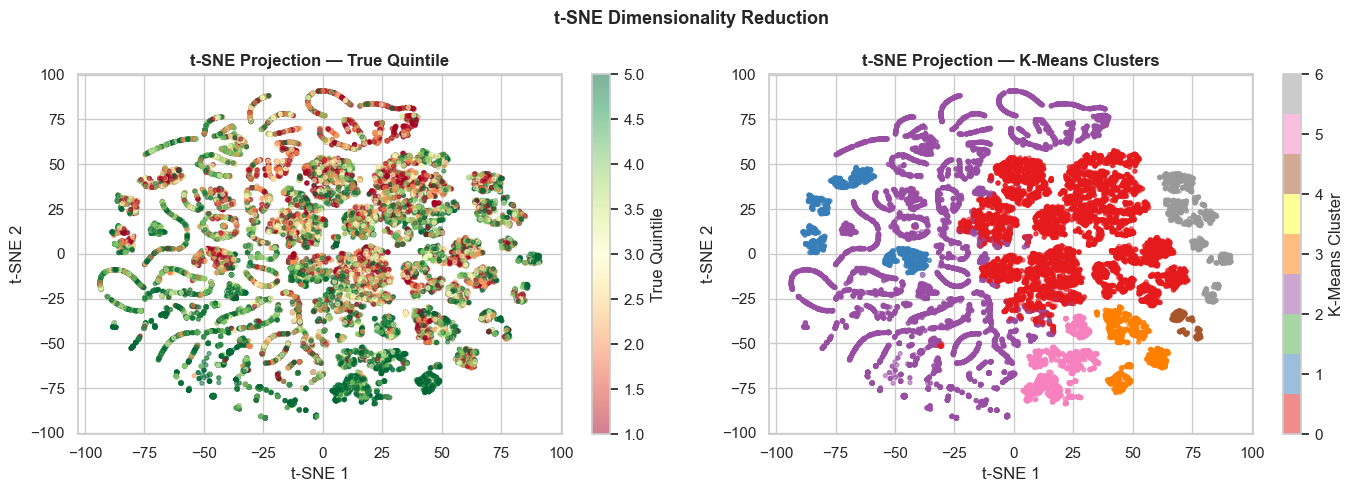

In [12]:
# t-SNE (Chapter 4 Lab 4.3 Exercise 7) — use PCA-reduced input for speed
print("Running t-SNE (this may take 30–60 seconds)…")
X_pca50 = PCA(n_components=min(50, X_scaled.shape[1])).fit_transform(X_scaled)
tsne    = TSNE(n_components=2, random_state=42, perplexity=30,
               learning_rate=200, max_iter=1000)
X_tsne  = tsne.fit_transform(X_pca50)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

scatter1 = axes[0].scatter(X_tsne[:,0], X_tsne[:,1],
                            c=y_true, cmap='RdYlGn', alpha=0.5, s=8)
plt.colorbar(scatter1, ax=axes[0], label='True Quintile')
axes[0].set_title('t-SNE Projection — True Quintile', fontweight='bold')
axes[0].set_xlabel('t-SNE 1'); axes[0].set_ylabel('t-SNE 2')

scatter2 = axes[1].scatter(X_tsne[:,0], X_tsne[:,1],
                            c=km_labels, cmap='Set1', alpha=0.5, s=8)
plt.colorbar(scatter2, ax=axes[1], label='K-Means Cluster')
axes[1].set_title('t-SNE Projection — K-Means Clusters', fontweight='bold')
axes[1].set_xlabel('t-SNE 1'); axes[1].set_ylabel('t-SNE 2')

plt.suptitle('t-SNE Dimensionality Reduction', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/tsne_projection.png', dpi=150, bbox_inches='tight')
plt.show()

### Exercise 7: LDA — Linear Discriminant Analysis (Chapter 4 Lab 4.3)

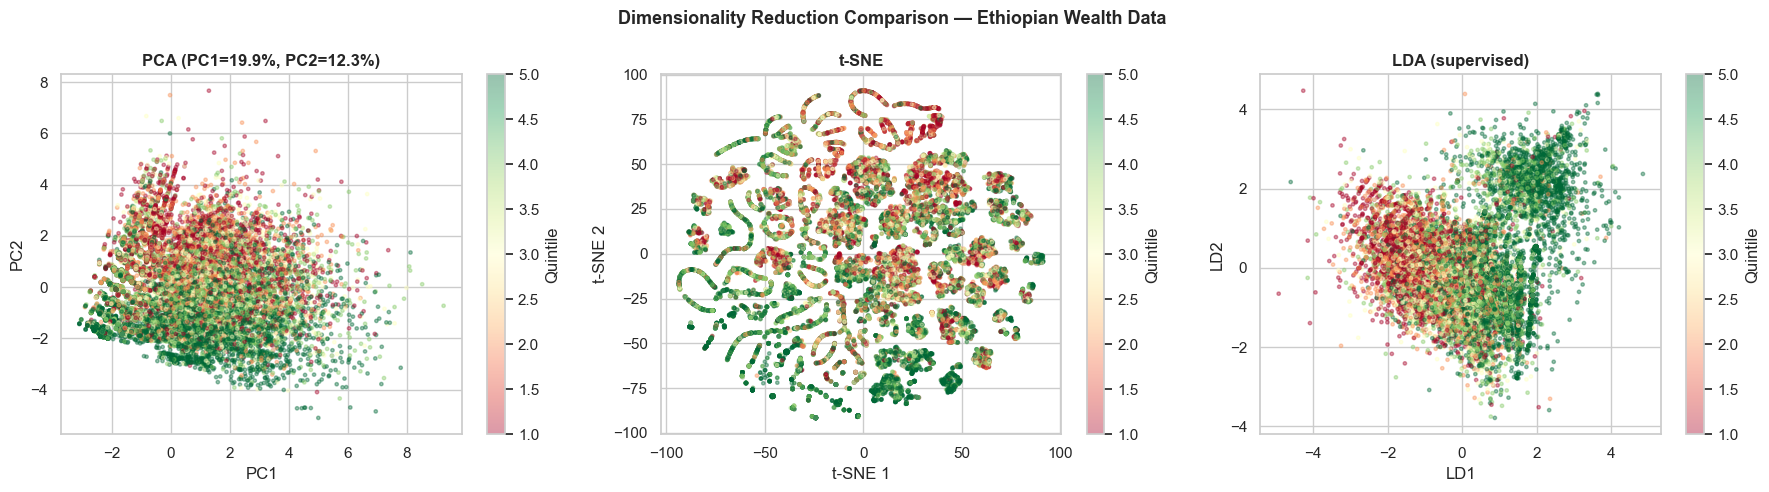

LDA explained variance ratio: [0.97397716 0.01989226]


In [14]:
# LDA (Chapter 4 Lab 4.3 Exercise 8) — supervised, uses true quintile labels
lda    = LinearDiscriminantAnalysis(n_components=2)
X_lda  = lda.fit_transform(X_scaled, y_true)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# PCA
scatter1 = axes[0].scatter(X_pca_2d[:,0], X_pca_2d[:,1],
                            c=y_true, cmap='RdYlGn', alpha=0.4, s=6)
axes[0].set_title(f'PCA (PC1={exp_var[0]:.1%}, PC2={exp_var[1]:.1%})',
                  fontweight='bold')
axes[0].set_xlabel('PC1'); axes[0].set_ylabel('PC2')
plt.colorbar(scatter1, ax=axes[0], label='Quintile')

# t-SNE
scatter2 = axes[1].scatter(X_tsne[:,0], X_tsne[:,1],
                            c=y_true, cmap='RdYlGn', alpha=0.4, s=6)
axes[1].set_title('t-SNE', fontweight='bold')
axes[1].set_xlabel('t-SNE 1'); axes[1].set_ylabel('t-SNE 2')
plt.colorbar(scatter2, ax=axes[1], label='Quintile')

# LDA
scatter3 = axes[2].scatter(X_lda[:,0], X_lda[:,1],
                            c=y_true, cmap='RdYlGn', alpha=0.4, s=6)
axes[2].set_title('LDA (supervised)', fontweight='bold')
axes[2].set_xlabel('LD1'); axes[2].set_ylabel('LD2')
plt.colorbar(scatter3, ax=axes[2], label='Quintile')

plt.suptitle('Dimensionality Reduction Comparison — Ethiopian Wealth Data',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/dim_reduction_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"LDA explained variance ratio: {lda.explained_variance_ratio_}")

## Part 3: Cluster Profile Analysis
Understanding what each cluster represents in terms of wealth indicators.


In [15]:
# Profile the K-Means clusters
df_cluster['km_cluster'] = km_labels[:len(df_cluster)]

profile = (df_cluster.groupby('km_cluster')[cluster_features + ['cons_quint']]
             .mean().round(3))

print("K-Means Cluster Profiles (feature means):")
profile


K-Means Cluster Profiles (feature means):


,rooms,housing_score,housing_quality_idx,has_electricity,owns_phone,owns_tv,owns_fridge,modern_asset_score,improved_water,improved_sanitation,head_edu_level,hh_size,adulteq,dependency_ratio,hh_any_wage_earner,is_urban,cons_quint
km_cluster,,,,,,,,,,,,,,,,,
0,12.693,0.544,0.585,0.000,0.0,0.000,0.000,0.000,1.000,0.799,2.529,4.842,3.910,0.189,0.276,0.011,3.053
1,1.465,0.208,0.616,1.000,0.0,0.000,0.000,0.000,0.995,0.998,1.016,4.524,3.682,0.179,0.437,0.385,2.836
2,1.792,0.129,0.611,0.000,0.0,0.000,0.000,0.000,1.000,1.000,1.007,4.271,3.516,0.168,0.429,0.542,3.457
3,11.275,0.591,0.554,0.006,0.0,1.000,0.000,2.000,0.762,0.749,2.366,4.605,3.750,0.179,0.221,0.043,3.624
4,10.051,0.536,0.547,0.011,1.0,0.333,0.141,2.091,0.801,0.953,2.591,4.841,3.912,0.180,0.272,0.062,3.725
5,11.849,0.481,0.425,0.011,0.0,0.000,0.000,0.000,0.000,0.811,2.020,4.003,3.341,0.158,0.202,0.032,4.400
6,12.155,0.568,0.554,0.008,0.0,0.126,1.000,3.251,0.849,0.859,2.496,5.450,4.466,0.174,0.250,0.064,3.526


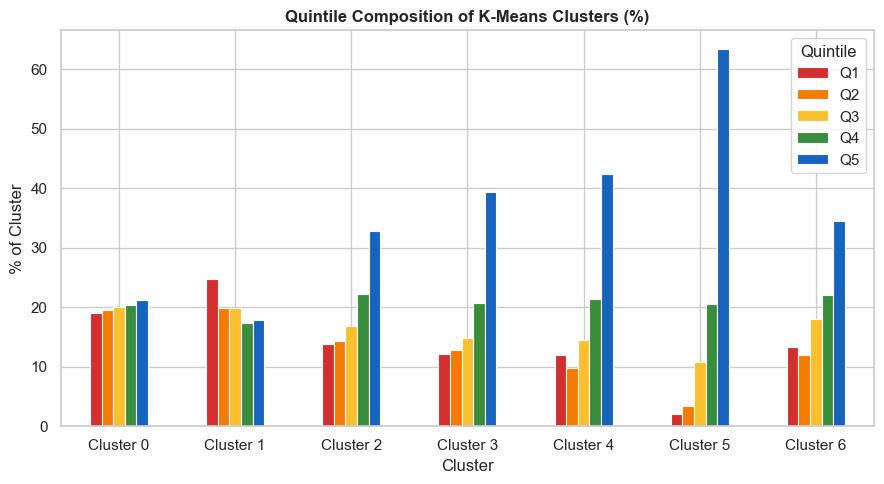

In [16]:
# Quintile composition per cluster (cross-tabulation)
ct = pd.crosstab(df_cluster['km_cluster'], df_cluster['cons_quint'],
                 normalize='index') * 100

fig, ax = plt.subplots(figsize=(9, 5))
ct.plot(kind='bar', ax=ax, color=COLORS5, edgecolor='white', linewidth=0.8)
ax.set_title('Quintile Composition of K-Means Clusters (%)', fontweight='bold')
ax.set_xlabel('Cluster'); ax.set_ylabel('% of Cluster')
ax.set_xticklabels([f'Cluster {i}' for i in ct.index], rotation=0)
ax.legend(title='Quintile', labels=[f'Q{i}' for i in range(1,6)])
plt.tight_layout()
plt.savefig('../reports/cluster_quintile_composition.png', dpi=150, bbox_inches='tight')
plt.show()
